# Dyslexia Screening System — Phase 1: Foundation Model (Masked Autoencoder)

**Dataset:** OneStop Movements (1000 Hz) via `pymovements`  
**Platform:** Kaggle (GPU recommended)  
**Feature Vector:** `[duration_ms, centroid_x, centroid_y, amplitude, regression_flag, efficiency_ratio]` → 6-dimensional

---


BLOCK 0 — Install dependencies

---
Run this cell first, then restart the kernel if prompted.
!pip install pymovements --quiet
!pip install tensorflow --quiet

In [9]:
!pip install pymovements --quiet
!pip install tensorflow --quiet

BLOCK 1 — Imports & global constants

---

In [10]:
import os
import glob
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import scipy
import sklearn
import tensorflow as tf
import tqdm

print("Library Versions:\n")

print(f"os: built-in (no version)")
print(f"glob: built-in (no version)")
print(f"pickle: built-in (no version)")
print(f"warnings: built-in (no version)")

print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"scipy: {scipy.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"tensorflow: {tf.__version__}")
print(f"tqdm: {tqdm.__version__}")

print("\nHardware Info:")
print("GPUs available:", tf.config.list_physical_devices('GPU'))

# ── I-DT production parameters (locked) ──────────────────────────────────────
DISPERSION_THRESHOLD = 0.041   # normalised screen units (same across all datasets)
DURATION_THRESHOLD_MS = 100    # minimum fixation duration in ms

# ── Sequence parameters ───────────────────────────────────────────────────────
SEQUENCE_LENGTH = 20            # fixations per sequence window
STEP           = 5              # sliding-window stride
N_FEATURES     = 6              # [duration, cx, cy, amplitude, regression, efficiency]

# ── Autoencoder / training ────────────────────────────────────────────────────
MASK_TOKEN     = -99.0          # sentinel value — far outside normalised range
MASK_FRACTION  = 0.15           # 15 % of timesteps masked per sequence
LATENT_DIM     = 64
BATCH_SIZE     = 256
EPOCHS         = 50
ATTENTION_HEADS  = 4
ATTENTION_KEY_DIM = 16

# ── Paths (Kaggle) ────────────────────────────────────────────────────────────
DATA_DIR    = 'data/OneStop'
OUTPUT_DIR  = '/kaggle/working'

# ── Numerical stability ───────────────────────────────────────────────────────
EPSILON            = 1e-6
EFFICIENCY_CAP     = 1000000      # hard cap on duration / amplitude ratio
                                 # prevents micro-saccade explosions

print("Constants locked.")

Library Versions:

os: built-in (no version)
glob: built-in (no version)
pickle: built-in (no version)
warnings: built-in (no version)
numpy: 2.0.2
pandas: 2.3.3
matplotlib: 3.10.0
seaborn: 0.13.2
scipy: 1.16.3
scikit-learn: 1.6.1
tensorflow: 2.19.0
tqdm: 4.67.3

Hardware Info:
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Constants locked.


BLOCK 2 — Download OneStop dataset via pymovements

---

In [11]:
import pymovements as pm

print("Downloading OneStop dataset …")
dataset = pm.Dataset('OneStop', path=DATA_DIR)
dataset.download()

# Load the fixation CSV that pymovements extracts
FIXATION_CSV = os.path.join(
    DATA_DIR, 'precomputed_events', 'fixations_Paragraph.csv'
)
print(f"Loading {FIXATION_CSV} …")
NEEDED_COLS = [
    'participant_id', 'TRIAL_INDEX', 'CURRENT_FIX_INDEX',
    'CURRENT_FIX_BLINK_AROUND', 'CURRENT_FIX_DURATION',
    'CURRENT_FIX_X', 'CURRENT_FIX_Y', 'PREVIOUS_SAC_AMPLITUDE'
]
df_raw = pd.read_csv(FIXATION_CSV, usecols=NEEDED_COLS,
                     dtype={'CURRENT_FIX_BLINK_AROUND': 'category'})
print(f"Raw shape: {df_raw.shape}")
print("Columns sample:", list(df_raw.columns[:12]))

INFO:pymovements.dataset.dataset:
        You are downloading the OneStop: A 360-Participant English Eye Tracking Dataset with Different Reading Regimes. Please be aware that pymovements does not
        host or distribute any dataset resources and only provides a convenient interface to
        download the public dataset resources that were published by their respective authors.

        Please cite the referenced publication if you intend to use the dataset in your research.
        


Using already downloaded and verified file: data/OneStop/downloads/fixations_Paragraph.csv.zip
Using already downloaded and verified file: data/OneStop/downloads/ia_Paragraph.csv.zip
Extracting fixations_Paragraph.csv.zip to data/OneStop/precomputed_events


Extracting archive: 100%|██████████| 1/1 [00:25<00:00, 25.03s/file]


Extracting ia_Paragraph.csv.zip to data/OneStop/precomputed_reading_measures


Extracting archive: 100%|██████████| 1/1 [00:21<00:00, 21.22s/file]


Loading data/OneStop/precomputed_events/fixations_Paragraph.csv …
Raw shape: (2400788, 8)
Columns sample: ['participant_id', 'TRIAL_INDEX', 'CURRENT_FIX_BLINK_AROUND', 'CURRENT_FIX_DURATION', 'CURRENT_FIX_INDEX', 'CURRENT_FIX_X', 'CURRENT_FIX_Y', 'PREVIOUS_SAC_AMPLITUDE']


BLOCK 3 — Data Cleaning
Remove blink-contaminated fixations and apply duration bounds.
Duration range relaxed to (50, 1500) ms matching production I-DT settings.

---

In [12]:
print("--- Block 3: Data Cleaning ---")

initial = len(df_raw)

# 1. Drop blink-contaminated rows
df_clean = df_raw[df_raw['CURRENT_FIX_BLINK_AROUND'] == 'NONE'].copy()
del df_raw  
print(f"Removed {initial - len(df_clean):,} blink-contaminated rows.")

# 2. Duration filter — matches webcam I-DT minimum (50 ms) and hard cap (1500 ms)
before_dur = len(df_clean)
df_clean = df_clean[df_clean['CURRENT_FIX_DURATION'].between(50, 1500)].copy()
print(f"Removed {before_dur - len(df_clean):,} rows outside 50–1500 ms range.")
print(f"Rows remaining: {len(df_clean):,}")

# Ensure numeric types on the columns we need
for col in ['CURRENT_FIX_DURATION', 'CURRENT_FIX_X', 'CURRENT_FIX_Y',
            'PREVIOUS_SAC_AMPLITUDE', 'CURRENT_FIX_INDEX']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean.dropna(subset=['CURRENT_FIX_DURATION', 'CURRENT_FIX_X',
                         'CURRENT_FIX_Y', 'CURRENT_FIX_INDEX'], inplace=True)
df_clean['PREVIOUS_SAC_AMPLITUDE'] = df_clean['PREVIOUS_SAC_AMPLITUDE'].fillna(0.0)
print("Numeric coercion done.")

--- Block 3: Data Cleaning ---
Removed 252,136 blink-contaminated rows.
Removed 26,688 rows outside 50–1500 ms range.
Rows remaining: 2,121,964
Numeric coercion done.


BLOCK 4 — Screen normalisation
Normalise X/Y to [0, 1] using the reported screen resolution.

---

In [13]:
print("--- Block 4: Screen Normalisation ---")

# OneStop was presented on 1680 × 1050 displays
SCREEN_W = 1680.0
SCREEN_H = 1050.0
SCREEN_DIAG = np.sqrt(SCREEN_W**2 + SCREEN_H**2)   # ≈ 1984 px

df_clean['norm_x']   = df_clean['CURRENT_FIX_X']        / SCREEN_W
df_clean['norm_y']   = df_clean['CURRENT_FIX_Y']        / SCREEN_H
df_clean['norm_amp'] = df_clean['PREVIOUS_SAC_AMPLITUDE'] / SCREEN_DIAG

print("X, Y, amplitude normalised to [0, 1] range.")
print(df_clean[['norm_x', 'norm_y', 'norm_amp']].describe().round(4))

--- Block 4: Screen Normalisation ---
X, Y, amplitude normalised to [0, 1] range.
             norm_x        norm_y      norm_amp
count  2.121964e+06  2.121964e+06  2.121964e+06
mean   7.159000e-01  5.179000e-01  2.500000e-03
std    3.037000e-01  2.529000e-01  3.000000e-03
min   -1.261400e+00 -9.410000e-01  0.000000e+00
25%    4.395000e-01  3.038000e-01  1.000000e-03
50%    7.079000e-01  4.985000e-01  1.600000e-03
75%    9.855000e-01  7.107000e-01  2.600000e-03
max    1.946400e+00  2.649200e+00  2.350000e-02


BLOCK 7 — Feature Engineering
Final 6-dimensional vector per fixation:
[duration_ms, centroid_x, centroid_y, amplitude, regression_flag, efficiency_ratio]

---

In [14]:
print("--- Block 7: Feature Engineering ---")

# Sort once — all per-trial computations below depend on temporal order
df_clean = df_clean.sort_values(
    ['participant_id', 'TRIAL_INDEX', 'CURRENT_FIX_INDEX']
).reset_index(drop=True)

# ── Feature 1-3: duration, x, y (already normalised) ────────────────────────
df_clean['feat_duration'] = df_clean['CURRENT_FIX_DURATION'].astype(float)
df_clean['feat_x']        = df_clean['norm_x'].astype(float)
df_clean['feat_y']        = df_clean['norm_y'].astype(float)

# ── Feature 4: saccade amplitude (already normalised) ────────────────────────
df_clean['feat_amplitude'] = df_clean['norm_amp'].astype(float)

# ── Feature 5: IS_REGRESSION ─────────────────────────────────────────────────
# 1 if current fixation X < previous fixation X within the same trial
# (first fixation of each trial = 0 by definition)
grp = df_clean.groupby(['participant_id', 'TRIAL_INDEX'])
df_clean['prev_x'] = grp['feat_x'].shift(1)
df_clean['feat_regression'] = (
    (df_clean['feat_x'] < df_clean['prev_x']) &
    df_clean['prev_x'].notna()
).astype(int)
df_clean.drop(columns=['prev_x'], inplace=True)

if 'prev_y' in df_clean.columns:
    df_clean.drop(columns=['prev_y'], inplace=True)
    
# ── Feature 6: Efficiency Ratio (Log-Scaled) ─────────────────────────────────
# Captures "Processing Efficiency": Duration relative to Saccadic Amplitude.
# High values = High cognitive load/struggle (long stare, tiny jump).
# We use log1p to compress the 10^6 range into a stable 0-15 range.

# 1. Constants 
AMPLITUDE_FLOOR = 0.0001  # Prevents division by zero/near-zero
EFFICIENCY_CAP  = 20.0   # Caps outliers beyond the 99th percentile (log-space)

# 2. Identify first fixations to avoid "leakage" from previous trials
grp = df_clean.groupby(['participant_id', 'TRIAL_INDEX'])
is_first = grp['feat_amplitude'].shift(1).isna()

# 3. Prevent Mathematical Explosions
# We apply a floor to the denominator so the ratio doesn't hit infinity
safe_amp = np.maximum(df_clean['feat_amplitude'], AMPLITUDE_FLOOR)

# 4. Calculate Log-Efficiency
# Formula: ln(1 + duration / amplitude)
# This maps our 190,000 mean onto a ~11.6 mean.
raw_log_ratio = np.log1p(df_clean['feat_duration'] / safe_amp)

# 5. Apply Masks and Final Cap
df_clean['feat_efficiency'] = np.where(
    is_first,
    0.0,                                      # First fixation of trial is 0.0
    np.clip(raw_log_ratio, 0.0, EFFICIENCY_CAP) # Cap extreme micro-jitter noise
)

# Cleanup temporary calculation columns
if 'prev_amp' in df_clean.columns:
    df_clean.drop(columns=['prev_amp'], inplace=True)

print(f"Efficiency Ratio (Log) — Mean: {df_clean['feat_efficiency'].mean():.2f}, "
      f"Max: {df_clean['feat_efficiency'].max():.2f}, "
      f"Std: {df_clean['feat_efficiency'].std():.2f}")

FEATURE_COLS = [
    'feat_duration', 'feat_x', 'feat_y',
    'feat_amplitude', 'feat_regression', 'feat_efficiency'
]

print("Feature engineering complete.")
print(df_clean[FEATURE_COLS].describe().round(4))
print(f"\nRegression rate: {df_clean['feat_regression'].mean():.3f}")

print(f"Efficiency ratio — mean: {df_clean['feat_efficiency'].mean():.2f}, "
      f"max: {df_clean['feat_efficiency'].max():.2f}")

--- Block 7: Feature Engineering ---
Efficiency Ratio (Log) — Mean: 11.46, Max: 16.39, Std: 1.56
Feature engineering complete.
       feat_duration        feat_x        feat_y  feat_amplitude  \
count   2.121964e+06  2.121964e+06  2.121964e+06    2.121964e+06   
mean    1.956387e+02  7.159000e-01  5.179000e-01    2.500000e-03   
std     8.132810e+01  3.037000e-01  2.529000e-01    3.000000e-03   
min     5.000000e+01 -1.261400e+00 -9.410000e-01    0.000000e+00   
25%     1.460000e+02  4.395000e-01  3.038000e-01    1.000000e-03   
50%     1.800000e+02  7.079000e-01  4.985000e-01    1.600000e-03   
75%     2.300000e+02  9.855000e-01  7.107000e-01    2.600000e-03   
max     1.498000e+03  1.946400e+00  2.649200e+00    2.350000e-02   

       feat_regression  feat_efficiency  
count     2.121964e+06     2.121964e+06  
mean      3.204000e-01     1.145940e+01  
std       4.666000e-01     1.557100e+00  
min       0.000000e+00     0.000000e+00  
25%       0.000000e+00     1.108600e+01  
50%     

--- Block 7.5: Feature Analysis & Visualization ---

--- Descriptive Statistics (Post-Processing) ---
       feat_duration      feat_x      feat_y  feat_amplitude  feat_regression  \
count     2121964.00  2121964.00  2121964.00      2121964.00       2121964.00   
mean          195.64        0.72        0.52            0.00             0.32   
std            81.33        0.30        0.25            0.00             0.47   
min            50.00       -1.26       -0.94            0.00             0.00   
5%             94.00        0.27        0.18            0.00             0.00   
25%           146.00        0.44        0.30            0.00             0.00   
50%           180.00        0.71        0.50            0.00             0.00   
75%           230.00        0.99        0.71            0.00             1.00   
95%           338.00        1.19        0.97            0.01             1.00   
99%           475.00        1.24        1.15            0.01             1.00   
max    

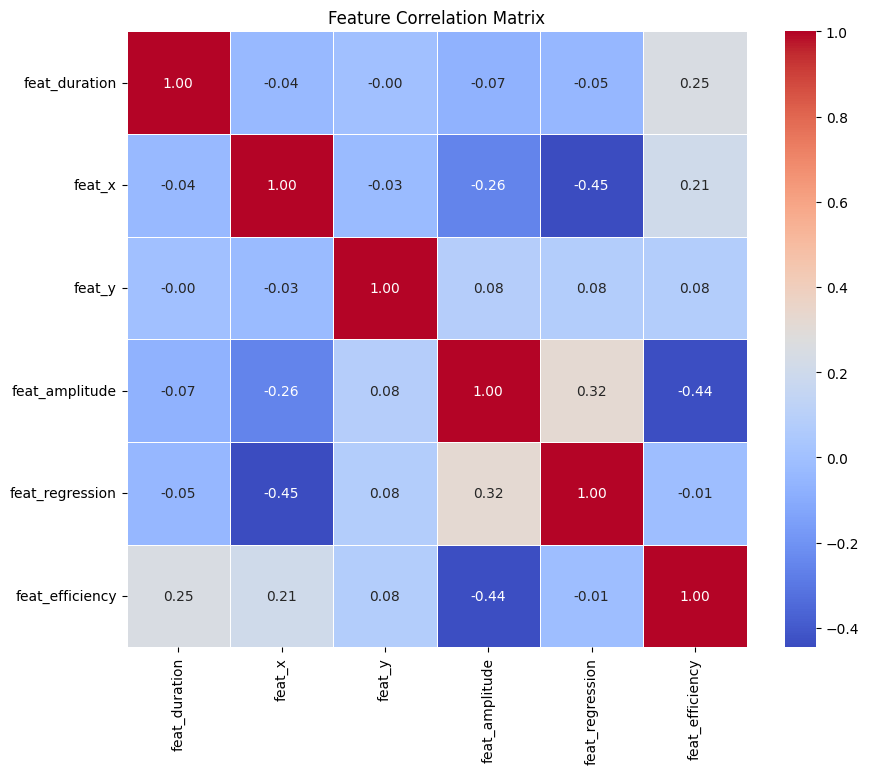

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/tmp/ipykernel_55/1389678308.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, ax=axes[i], palette='viridis')
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


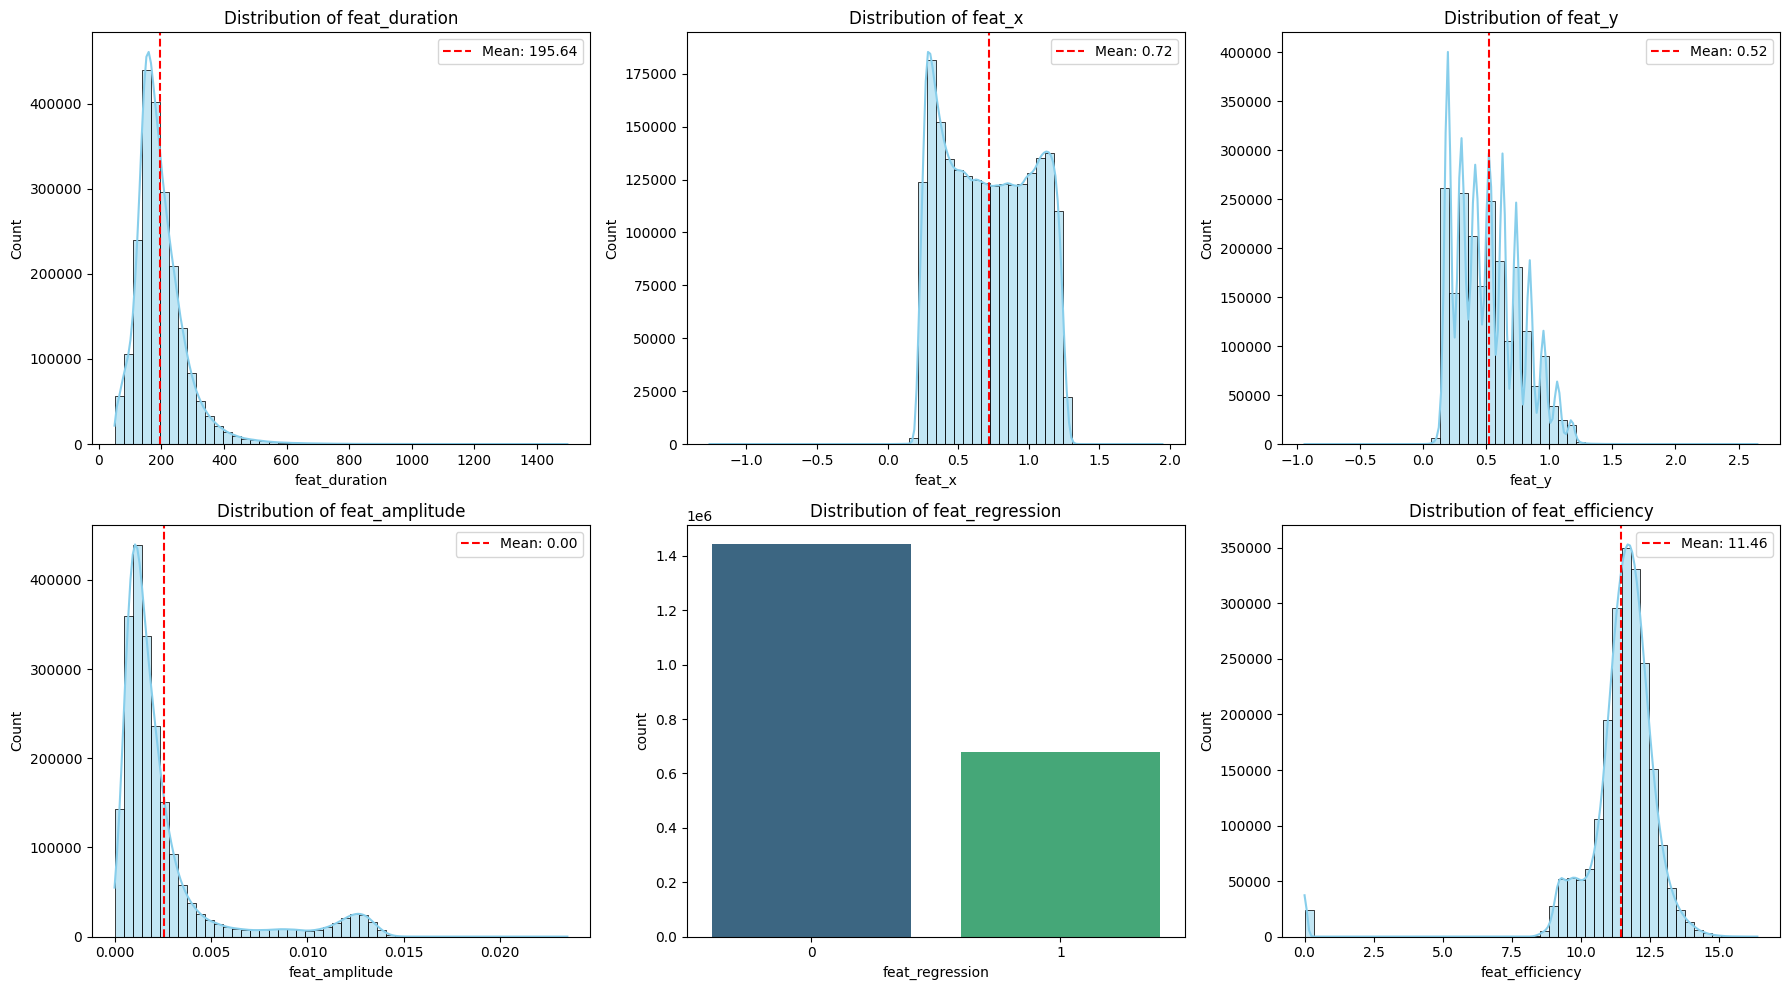


--- Efficiency Ratio Outlier Check ---
99th Percentile: 13.82
Samples at Hard Cap (20.0): 0 (0.000%)


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Block 7.5: Feature Analysis & Visualization ---")

# 1. Select the final feature set
FEATURE_COLS = [
    'feat_duration', 'feat_x', 'feat_y', 
    'feat_amplitude', 'feat_regression', 'feat_efficiency'
]

# 2. Print Detailed Statistics
print("\n--- Descriptive Statistics (Post-Processing) ---")
stats = df_clean[FEATURE_COLS].describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(2)
print(stats)

# 3. Correlation Heatmap
# We check if 'feat_efficiency' is redundant with duration or unique.
plt.figure(figsize=(10, 8))
corr_matrix = df_clean[FEATURE_COLS].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

# 4. Distribution Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    if col == 'feat_regression':
        # Categorical plot for the binary flag
        sns.countplot(data=df_clean, x=col, ax=axes[i], palette='viridis')
        axes[i].set_title(f"Distribution of {col}")
    else:
        # Distribution plot for continuous features
        sns.histplot(df_clean[col], bins=50, kde=True, ax=axes[i], color='skyblue')
        axes[i].set_title(f"Distribution of {col}")
        
        # Add a vertical line for the mean
        axes[i].axvline(df_clean[col].mean(), color='red', linestyle='--', label=f'Mean: {df_clean[col].mean():.2f}')
        axes[i].legend()

plt.tight_layout()
plt.show()

# 5. Efficiency Ratio "Deep Dive"
print("\n--- Efficiency Ratio Outlier Check ---")
perc_99 = df_clean['feat_efficiency'].quantile(0.99)
at_cap = (df_clean['feat_efficiency'] >= EFFICIENCY_CAP).sum()
print(f"99th Percentile: {perc_99:.2f}")
print(f"Samples at Hard Cap ({EFFICIENCY_CAP}): {at_cap} ({at_cap/len(df_clean)*100:.3f}%)")

BLOCK 8 — Sequence Generation
Sliding window of length SEQUENCE_LENGTH, stride STEP.
One row per sequence; participant + trial tracked for train/val split.

---

In [18]:
from tqdm.notebook import tqdm
print("--- Block 8: Sequence Generation ---")

all_sequences    = []
participant_tags = []      # for participant-level train/val split

grouped = df_clean.groupby(['participant_id', 'TRIAL_INDEX'])

for (pid, tid), group in tqdm(grouped, desc="Building sequences"):
    trial_feats = group[FEATURE_COLS].values.astype(np.float32)
    n = len(trial_feats)
    if n < SEQUENCE_LENGTH:
        continue
    for start in range(0, n - SEQUENCE_LENGTH + 1, STEP):
        all_sequences.append(trial_feats[start : start + SEQUENCE_LENGTH])
        participant_tags.append(pid)

X = np.array(all_sequences, dtype=np.float32)
participant_tags = np.array(participant_tags)

print(f"Total sequences: {X.shape[0]:,}")
print(f"Sequence shape : {X.shape[1:]}  (should be ({SEQUENCE_LENGTH}, {N_FEATURES}))")

--- Block 8: Sequence Generation ---


Building sequences:   0%|          | 0/24046 [00:00<?, ?it/s]

Total sequences: 342,893
Sequence shape : (20, 6)  (should be (20, 6))


BLOCK 9 — Participant-Level Train / Validation Split + StandardScaler

---
Split is done at the PARTICIPANT level so no participant's data leaks
between train and val.  Scaling is fit ONLY on training sequences.

---

In [19]:
print("--- Block 9: Train/Val Split & Normalisation ---")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

unique_pids = np.unique(participant_tags)
train_pids, val_pids = train_test_split(unique_pids, test_size=0.15,
                                         random_state=42)

train_mask = np.isin(participant_tags, train_pids)
val_mask   = np.isin(participant_tags, val_pids)

X_train_raw = X[train_mask]
X_val_raw   = X[val_mask]

print(f"Training participants : {len(train_pids)} → {X_train_raw.shape[0]:,} sequences")
print(f"Validation participants: {len(val_pids)}  → {X_val_raw.shape[0]:,} sequences")

# Fit scaler on flattened training data, transform both splits
scaler = StandardScaler()
scaler.fit(X_train_raw.reshape(-1, N_FEATURES))

X_train = scaler.transform(
    X_train_raw.reshape(-1, N_FEATURES)
).reshape(X_train_raw.shape).astype(np.float32)

X_val = scaler.transform(
    X_val_raw.reshape(-1, N_FEATURES)
).reshape(X_val_raw.shape).astype(np.float32)

print(f"\nX_train mean ≈ {X_train.mean():.4f} (target: ~0)")
print(f"X_train std  ≈ {X_train.std():.4f}  (target: ~1)")

# Save scaler
scaler_path = os.path.join(OUTPUT_DIR, 'scaler_v3.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved → {scaler_path}")

# Sanity: confirm MASK_TOKEN is outside the normalised range
feat_min = X_train.min()
feat_max = X_train.max()
print(f"\nNormalised data range: [{feat_min:.2f}, {feat_max:.2f}]")
print(f"MASK_TOKEN = {MASK_TOKEN}  ← should be far below {feat_min:.2f}  ✓"
      if MASK_TOKEN < feat_min - 5 else
      f"WARNING: MASK_TOKEN {MASK_TOKEN} may overlap with data range!")

--- Block 9: Train/Val Split & Normalisation ---
Training participants : 306 → 289,191 sequences
Validation participants: 54  → 53,702 sequences

X_train mean ≈ -0.0000 (target: ~0)
X_train std  ≈ 1.0000  (target: ~1)
Scaler saved → /kaggle/working/scaler_v3.pkl

Normalised data range: [-9.74, 15.90]
MASK_TOKEN = -99.0  ← should be far below -9.74  ✓


BLOCK 10 — Masked Autoencoder Data Pipeline

---
For each sequence the pipeline:
1. Randomly selects MASK_FRACTION of timesteps.
2. Replaces those timesteps with MASK_TOKEN (not 0.0).
3. Returns (masked_sequence, original_sequence) pairs.

---
The model input is the masked sequence; the reconstruction target is the
original.  Loss is computed ONLY over masked positions.

---

In [20]:
# ── Constants (update in Block 4 / global constants section) ──────────────────
MASK_FRACTION    = 0.35       # was 0.15 — 7/20 positions masked, forces real learning
FEATURE_WEIGHTS  = np.array([2.0, 1.0, 1.0, 2.0, 1.5, 2.0], dtype=np.float32)
# ^ duration, x, y, amplitude, regression, efficiency
# Clinical features weighted higher — these carry the dyslexia signal

# ─────────────────────────────────────────────────────────────────────────────
print('BLOCK 10: tf.data pipeline  (unchanged logic, mask fraction now 0.35)')
# ─────────────────────────────────────────────────────────────────────────────
def mask_sequence_tf(sequence: tf.Tensor):
    seq_len   = tf.shape(sequence)[0]
    n_to_mask = tf.cast(
        tf.math.ceil(tf.cast(seq_len, tf.float32) * MASK_FRACTION), tf.int32
    )
    noise = tf.random.uniform([seq_len])
    _, mask_indices = tf.math.top_k(noise, k=n_to_mask)
    mask_bool = tf.reduce_any(
        tf.equal(tf.range(seq_len)[:, tf.newaxis], mask_indices[tf.newaxis, :]),
        axis=1
    )
    mask_expanded     = tf.cast(mask_bool, tf.float32)[:, tf.newaxis]
    mask_token_tensor = tf.fill(tf.shape(sequence), MASK_TOKEN)
    masked_seq = tf.where(
        tf.broadcast_to(mask_expanded > 0, tf.shape(sequence)),
        mask_token_tensor,
        sequence
    )
    return masked_seq, sequence, mask_bool


def build_dataset(X_data: np.ndarray, shuffle: bool = True) -> tf.data.Dataset:
    ds = tf.data.Dataset.from_tensor_slices(X_data)
    if shuffle:
        ds = ds.shuffle(buffer_size=min(50_000, len(X_data)), reshuffle_each_iteration=True)
    ds = ds.map(mask_sequence_tf, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_dataset(X_train, shuffle=True)
val_ds   = build_dataset(X_val,   shuffle=False)

BLOCK 10: tf.data pipeline  (unchanged logic, mask fraction now 0.35)


I0000 00:00:1776612190.354349      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


BLOCK 11 — Model Architecture

---
Input (masked)
└─ LSTM encoder layer 1  (128 units, return_sequences=True)
└─ Multi-Head Self-Attention  (4 heads × 16 key-dim)
+ Residual connection + LayerNorm
└─ LSTM encoder layer 2  (64 units, return_sequences=False)
→ context vector  [batch, 64]
└─ RepeatVector(20)
└─ LSTM decoder layer 1  (128 units, return_sequences=True)
└─ LSTM decoder layer 2  (N_FEATURES units, return_sequences=True)
└─ TimeDistributed Dense (N_FEATURES, linear)
Output (reconstruction of original 6 features at ALL timesteps)

---
Loss is computed only on masked positions (custom masked MSE).

---

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 11: Best Version So Far + Stronger Regularization
# ─────────────────────────────────────────────────────────────────────────────
from tensorflow.keras.layers import (
    Input, LSTM, Dropout, MultiHeadAttention, Add, LayerNormalization,
    RepeatVector, TimeDistributed, Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

def build_autoencoder(seq_len=SEQUENCE_LENGTH, 
                      n_features=N_FEATURES,
                      latent_dim=LATENT_DIM, 
                      n_heads=ATTENTION_HEADS,
                      key_dim=ATTENTION_KEY_DIM, 
                      dropout_rate=0.08,      # lowered
                      l2_reg=5e-6):
    
    encoder_input = Input(shape=(seq_len, n_features), name='encoder_input')

    # Encoder
    e1 = LSTM(latent_dim * 2, 
              return_sequences=True,
              kernel_regularizer=regularizers.l2(l2_reg),
              recurrent_regularizer=regularizers.l2(l2_reg),
              name='encoder_lstm_1')(encoder_input)
    e1 = Dropout(dropout_rate, name='encoder_dropout_1')(e1)

    attn_out = MultiHeadAttention(
        num_heads=n_heads, 
        key_dim=key_dim,
        dropout=dropout_rate, 
        name='encoder_mhsa'
    )(e1, e1)

    attn_out = Dropout(0.1, name='encoder_attention_dropout')(attn_out)

    attn_out = Add(name='encoder_residual')([e1, attn_out])
    attn_out = LayerNormalization(epsilon=1e-6, name='encoder_layernorm')(attn_out)
    attn_out = Dropout(0.1, name='encoder_post_norm_dropout')(attn_out)   # NEW

    context, h_enc, c_enc = LSTM(
        latent_dim, 
        return_sequences=False, 
        return_state=True,
        kernel_regularizer=regularizers.l2(l2_reg),
        recurrent_regularizer=regularizers.l2(l2_reg),
        name='encoder_lstm_2'
    )(attn_out)

    encoder = Model(encoder_input, context, name='gaze_encoder_v3')

    # Decoder
    repeated = RepeatVector(seq_len, name='repeat_vector')(context)

    d1 = LSTM(latent_dim * 2, 
              return_sequences=True,
              kernel_regularizer=regularizers.l2(l2_reg),
              recurrent_regularizer=regularizers.l2(l2_reg),
              name='decoder_lstm_1')(
        repeated,
        initial_state=[
            Dense(latent_dim * 2, kernel_regularizer=regularizers.l2(l2_reg), name='state_proj_h')(h_enc),
            Dense(latent_dim * 2, kernel_regularizer=regularizers.l2(l2_reg), name='state_proj_c')(c_enc),
        ]
    )

    d1 = Dropout(dropout_rate, name='decoder_dropout_1')(d1)

    d2 = LSTM(24,   # you already reduced this
              return_sequences=True,
              kernel_regularizer=regularizers.l2(l2_reg),
              recurrent_regularizer=regularizers.l2(l2_reg),
              name='decoder_lstm_2')(d1)
    
    d2 = Dropout(0.08, name='decoder_dropout_2')(d2)

    reconstruction = TimeDistributed(
        Dense(n_features, activation='linear')
    )(d2)

    autoencoder = Model(encoder_input, reconstruction, name='masked_autoencoder_v3')
    
    return autoencoder, encoder


autoencoder, encoder = build_autoencoder(dropout_rate=0.08, l2_reg=5e-6)
autoencoder.summary()

Model: "masked_autoencoder_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 20, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm_1      │ (None, 20, 128)   │     69,120 │ encoder_input[0]… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dropout_1   │ (None, 20, 128)   │          0 │ encoder_lstm_1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_mhsa        │ (None, 20, 128)   │     33,088 │ encoder_dropout_… │
│ (MultiHeadAttentio… │                   │            │ encoder_dropout_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_attention_… │ (None, 20, 128)   │          0 │ encoder_mhsa[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_residual    │ (None, 20, 128)   │          0 │ encoder_dropout_… │
│ (Add)               │                   │            │ encoder_attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layernorm   │ (None, 20, 128)   │        256 │ encoder_residual… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_post_norm_… │ (None, 20, 128)   │          0 │ encoder_layernor… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm_2      │ [(None, 64),      │     49,408 │ encoder_post_nor… │
│ (LSTM)              │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 20, 64)    │          0 │ encoder_lstm_2[0… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_proj_h        │ (None, 128)       │      8,320 │ encoder_lstm_2[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_proj_c        │ (None, 128)       │      8,320 │ encoder_lstm_2[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm_1      │ (None, 20, 128)   │     98,816 │ repeat_vector[0]… │
│ (LSTM)              │                   │            │ state_proj_h[0][… │
│                     │                   │            │ state_proj_c[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dropout_1   │ (None, 20, 128)   │          0 │ decoder_lstm_1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm_2      │ (None, 20, 24)    │     14,688 │ decoder_dropout_… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dropout_2   │ (None, 20, 24)    │          0 │ decoder_lstm_2[0… │
│ (Dropout)           │                   │            │                 

 Total params: 282,166 (1.08 MB)

 Trainable params: 282,166 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

BLOCK 12 — Custom Masked MSE Loss

---
Standard MSE penalises reconstruction error at EVERY timestep, including
unmasked ones the model saw in full. That makes it an easier task and
reduces the learning signal.

---
Masked MSE computes error ONLY at positions where the input was replaced
with MASK_TOKEN, so the model is penalised for exactly the "fill in the
blanks" task.

---
Implementation: we pass (masked_input, original, mask_bool) from the
dataset and use a custom train_step to route mask_bool into the loss.

---

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 12: Custom loss with mixed objective + correct metric tracking
# ─────────────────────────────────────────────────────────────────────────────
FEATURE_WEIGHTS_TF = tf.constant(FEATURE_WEIGHTS, dtype=tf.float32)  # (6,)

class MaskedAutoencoder(tf.keras.Model):

    def __init__(self, autoencoder_model: tf.keras.Model, warmup_epochs: int = 10):
        super().__init__()
        self.ae             = autoencoder_model
        self.warmup_epochs  = warmup_epochs
        self.current_epoch  = tf.Variable(0, trainable=False, dtype=tf.int32)
        # Separate trackers with distinct names — no bleed between phases
        self.train_loss_tracker = tf.keras.metrics.Mean(name='loss')
        self.val_loss_tracker   = tf.keras.metrics.Mean(name='val_loss')

    def call(self, inputs, training=False):
        return self.ae(inputs, training=training)

    def _full_mse(self, y_true, y_pred):
        """Weighted MSE over the entire sequence (used during warmup)."""
        sq_err = tf.square(y_true - y_pred) * FEATURE_WEIGHTS_TF  # (B, T, F)
        return tf.reduce_mean(sq_err)

    def _masked_mse(self, y_true, y_pred, mask_bool):
        """Weighted MSE over masked positions only."""
        mask      = tf.cast(mask_bool, tf.float32)[:, :, tf.newaxis]  # (B,T,1)
        sq_err    = tf.square(y_true - y_pred) * FEATURE_WEIGHTS_TF   # (B,T,F)
        masked_sq = sq_err * mask                                       # zero unmasked
        per_step  = tf.reduce_mean(masked_sq, axis=-1)                 # (B,T)
        sum_err   = tf.reduce_sum(per_step * mask[:, :, 0])
        n_masked  = tf.reduce_sum(mask[:, :, 0]) + EPSILON
        return sum_err / n_masked

    def _mixed_loss(self, y_true, y_pred, mask_bool):
        """
        Mixed objective: during warmup blend full-sequence MSE with masked MSE.
        alpha anneals from 0.5 -> 1.0 linearly over warmup_epochs.
        After warmup, pure masked MSE.

        This prevents mean-prediction collapse by forcing full reconstruction
        early in training, then gradually specialising to masked positions.
        """
        epoch_f = tf.cast(self.current_epoch, tf.float32)
        warmup_f = tf.cast(self.warmup_epochs, tf.float32)
        # alpha goes 0.5 -> 1.0 over warmup epochs, then stays at 1.0
        alpha = tf.minimum(1.0, 0.5 + 0.5 * (epoch_f / warmup_f))

        masked_loss = self._masked_mse(y_true, y_pred, mask_bool)
        full_loss   = self._full_mse(y_true, y_pred)
        return alpha * masked_loss + (1.0 - alpha) * full_loss

    def train_step(self, data):
        masked_seq, original_seq, mask_bool = data
        with tf.GradientTape() as tape:
            recon = self.ae(masked_seq, training=True)
            loss  = self._mixed_loss(original_seq, recon, mask_bool)
        grads = tape.gradient(loss, self.ae.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.ae.trainable_variables))
        self.train_loss_tracker.update_state(loss)
        return {'loss': self.train_loss_tracker.result()}

    def test_step(self, data):
        masked_seq, original_seq, mask_bool = data
        recon = self.ae(masked_seq, training=False)
        # Validation always uses pure masked MSE — this is the true performance signal
        loss  = self._masked_mse(original_seq, recon, mask_bool)
        self.val_loss_tracker.update_state(loss)
        return {'loss': self.val_loss_tracker.result()}

    @property
    def metrics(self):
        # Both trackers listed — Keras resets both at epoch boundaries
        return [self.train_loss_tracker, self.val_loss_tracker]

    def on_epoch_begin(self, epoch, logs=None):
        """Called by Keras at the start of each epoch to advance the counter."""
        self.current_epoch.assign(epoch)


mae_model = MaskedAutoencoder(autoencoder, warmup_epochs=10)
# Better optimizer with weight decay
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3,
    weight_decay=2e-4,    
    clipnorm=1.0
)

mae_model.compile(optimizer=optimizer)


# Sanity check
sample_masked = tf.fill([2, SEQUENCE_LENGTH, N_FEATURES], -99.0)
out = mae_model(sample_masked)
print(f"Forward-pass: {sample_masked.shape} → {out.shape}  ✓")

I0000 00:00:1776612192.945026     196 cuda_dnn.cc:529] Loaded cuDNN version 91002


Forward-pass: (2, 20, 6) → (2, 20, 6)  ✓


BLOCK 13 — Training

---

In [23]:
print("--- Block 13: Training the Masked Autoencoder ---")
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint_path = os.path.join(OUTPUT_DIR, 'best_masked_autoencoder_v3.keras')

            
callbacks = [
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        mode='min',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = mae_model.fit(
    train_ds,
    epochs=1000,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete.")
print(f"Best val_loss: {min(history.history['val_loss']):.6f}")

--- Block 13: Training the Masked Autoencoder ---
Epoch 1/1000
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.2566
Epoch 1: val_loss improved from inf to 0.94964, saving model to /kaggle/working/best_masked_autoencoder_v3.keras
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - loss: 1.2565 - val_loss: 0.9496 - learning_rate: 0.0010
Epoch 2/1000
1129/1130 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.8658
Epoch 2: val_loss improved from 0.94964 to 0.87569, saving model to /kaggle/working/best_masked_autoencoder_v3.keras
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 31s 28ms/step - loss: 0.8657 - val_loss: 0.8757 - learning_rate: 0.0010
Epoch 3/1000
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.8131
Epoch 3: val_loss improved from 0.87569 to 0.85139, saving model to /kaggle/working/best_masked_autoencoder_v3.keras
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 31s 27ms/step - loss: 0.8131 - val_loss: 0.8514 - learning_rate: 0.0010
Epoch 4/1000
1128/1130 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.7799
Epoch 

BLOCK 14 — Training History Plots

---

--- Block 14: Visualising Training History ---
Plot saved → /kaggle/working/training_history_v3.png


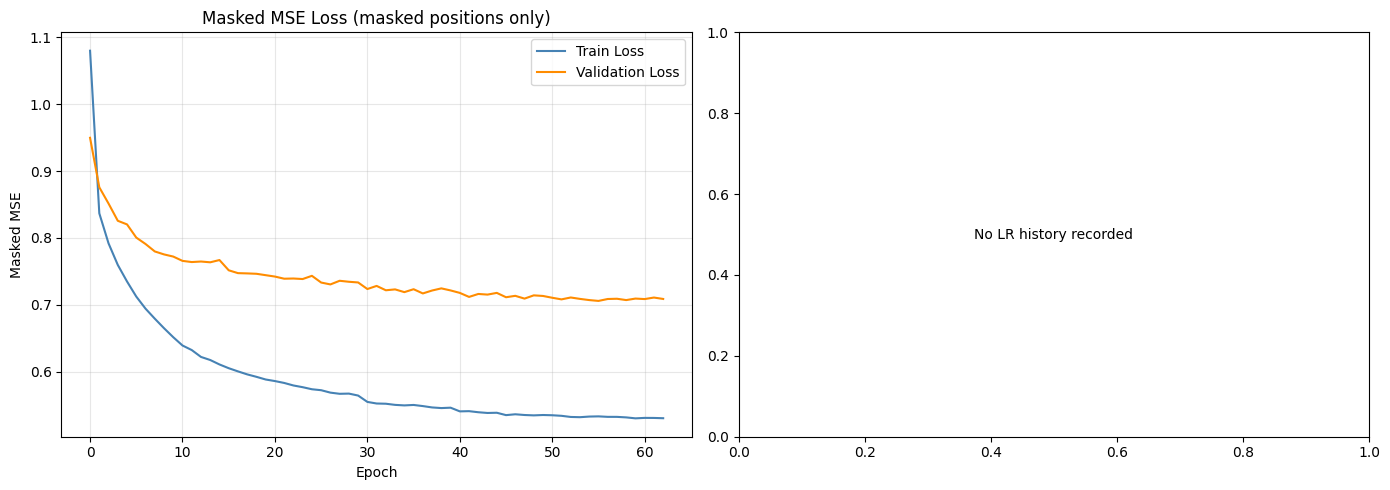

In [24]:
print("--- Block 14: Visualising Training History ---")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='darkorange')
axes[0].set_title('Masked MSE Loss (masked positions only)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Masked MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Learning rate curve (if ReduceLROnPlateau fired)
if 'lr' in history.history:
    axes[1].plot(history.history['learning_rate'], color='green')
    axes[1].set_title('Learning Rate Schedule')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('LR')
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No LR history recorded', ha='center', va='center')

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'training_history_v3.png')
plt.savefig(plot_path, dpi=150)
print(f"Plot saved → {plot_path}")
plt.show()

BLOCK 15 — Qualitative Reconstruction Sanity Check

---
Take one validation sequence, mask 20% of it, run through the autoencoder,
and plot original vs reconstruction for each of the 6 features.
A good encoder will produce smooth reconstructions that track the original
closely at masked positions.

---

--- Block 15: Reconstruction Sanity Check ---
Sanity check plot saved → /kaggle/working/reconstruction_sanity_v3.png


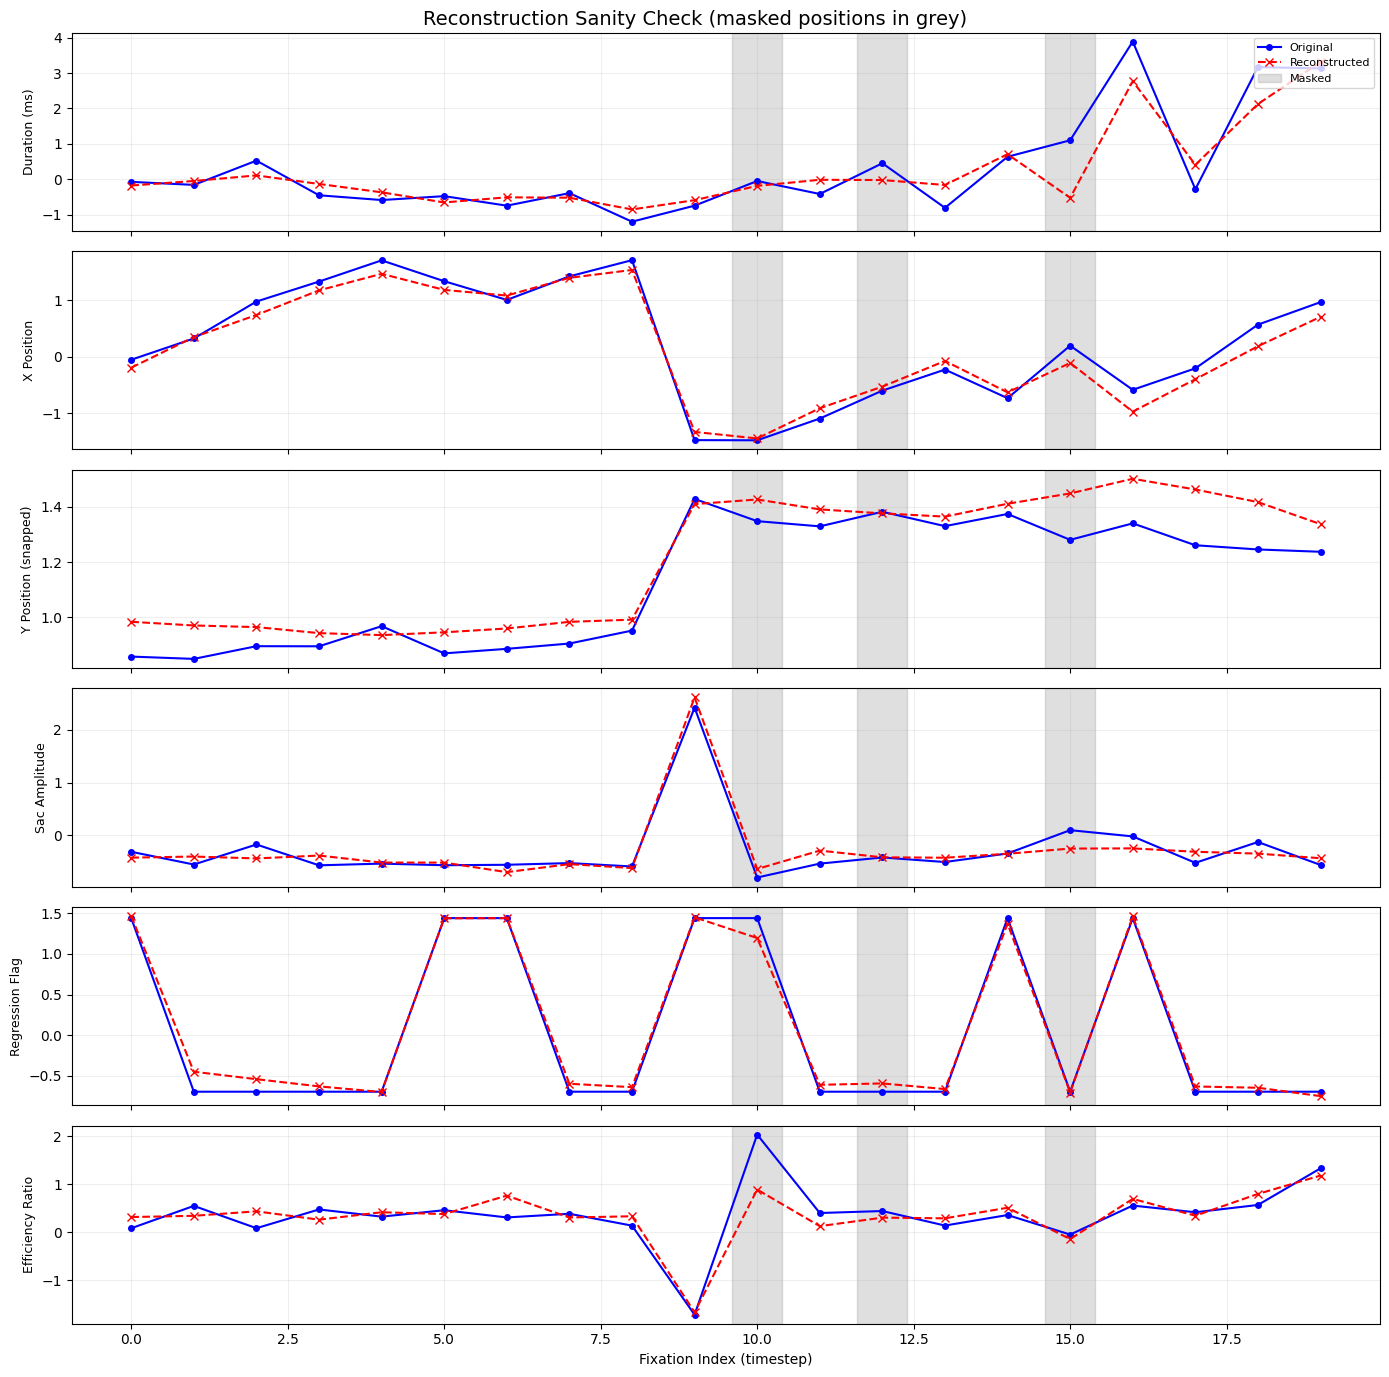

In [25]:
print("--- Block 15: Reconstruction Sanity Check ---")

FEATURE_NAMES = [
    'Duration (ms)', 'X Position', 'Y Position (snapped)',
    'Sac Amplitude', 'Regression Flag', 'Efficiency Ratio'
]

# Grab one clean sequence from validation data
sample_original = X_val[42].copy()   # shape (20, 6)

# Manually mask 4 timesteps (20%)
rng = np.random.default_rng(seed=0)
mask_idx = rng.choice(SEQUENCE_LENGTH, size=3, replace=False)
sample_masked = sample_original.copy()
sample_masked[mask_idx] = MASK_TOKEN

# Reconstruct
recon = autoencoder.predict(
    sample_masked[np.newaxis], verbose=0
)[0]   # shape (20, 6)

fig, axes = plt.subplots(N_FEATURES, 1, figsize=(14, 14), sharex=True)
fig.suptitle('Reconstruction Sanity Check (masked positions in grey)', fontsize=14)

for i, ax in enumerate(axes):
    ax.plot(sample_original[:, i], 'b-o',  markersize=4, label='Original')
    ax.plot(recon[:, i],           'r--x', markersize=6, label='Reconstructed')
    for mi in mask_idx:
        ax.axvspan(mi - 0.4, mi + 0.4, color='grey', alpha=0.25,
                   label='Masked' if mi == mask_idx[0] else '_')
    ax.set_ylabel(FEATURE_NAMES[i], fontsize=9)
    ax.grid(True, alpha=0.2)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Fixation Index (timestep)')
plt.tight_layout()
sanity_path = os.path.join(OUTPUT_DIR, 'reconstruction_sanity_v3.png')
plt.savefig(sanity_path, dpi=150)
print(f"Sanity check plot saved → {sanity_path}")
plt.show()

BLOCK 16 — Save Artefacts

---
Saved files (in /kaggle/working/):
gaze_encoder_v3.keras        ← Phase-2 input (classifier head training)
masked_autoencoder_v3.keras  ← full model checkpoint
scaler_v3.pkl                ← StandardScaler (apply to ALL downstream data)
X_train_source.npy           ← processed training sequences
X_val_source.npy             ← processed validation sequences

---

In [26]:
print("--- Block 16: Saving Phase-1 Artefacts ---")

# Save the standalone encoder (the reusable foundation model)
encoder_path = os.path.join(OUTPUT_DIR, 'gaze_encoder_v3.keras')
encoder.save(encoder_path)
print(f"Encoder saved         → {encoder_path}")

# Save the full autoencoder (for inspection / fine-tuning)
ae_path = os.path.join(OUTPUT_DIR, 'masked_autoencoder_v3.keras')
autoencoder.save(ae_path)
print(f"Autoencoder saved     → {ae_path}")

# Save processed sequences (for use in Phase-2 ETDD70 notebook)
np.save(os.path.join(OUTPUT_DIR, 'X_train_source.npy'), X_train)
np.save(os.path.join(OUTPUT_DIR, 'X_val_source.npy'),   X_val)
print(f"X_train_source saved  → {os.path.join(OUTPUT_DIR, 'X_train_source.npy')}")
print(f"X_val_source saved    → {os.path.join(OUTPUT_DIR, 'X_val_source.npy')}")

print("\n" + "="*60)
print("Phase 1 complete.  Artefacts ready for Phase 2 (ETDD70 classifier).")
print("="*60)
print(f"\nEncoder input shape : {encoder.input_shape}")
print(f"Encoder output shape: {encoder.output_shape}  ← 64-dim context vector")
print(f"Feature vector      : {FEATURE_COLS}")
print(f"Scaler              : {scaler_path}")

--- Block 16: Saving Phase-1 Artefacts ---
Encoder saved         → /kaggle/working/gaze_encoder_v3.keras
Autoencoder saved     → /kaggle/working/masked_autoencoder_v3.keras
X_train_source saved  → /kaggle/working/X_train_source.npy
X_val_source saved    → /kaggle/working/X_val_source.npy

Phase 1 complete.  Artefacts ready for Phase 2 (ETDD70 classifier).

Encoder input shape : (None, 20, 6)
Encoder output shape: (None, 64)  ← 64-dim context vector
Feature vector      : ['feat_duration', 'feat_x', 'feat_y', 'feat_amplitude', 'feat_regression', 'feat_efficiency']
Scaler              : /kaggle/working/scaler_v3.pkl
